
#### Teoría de Circuitos II - UTN.BA

# Tarea Semanal 2
#### Rodríguez Silvosa, Martín

### Consigna
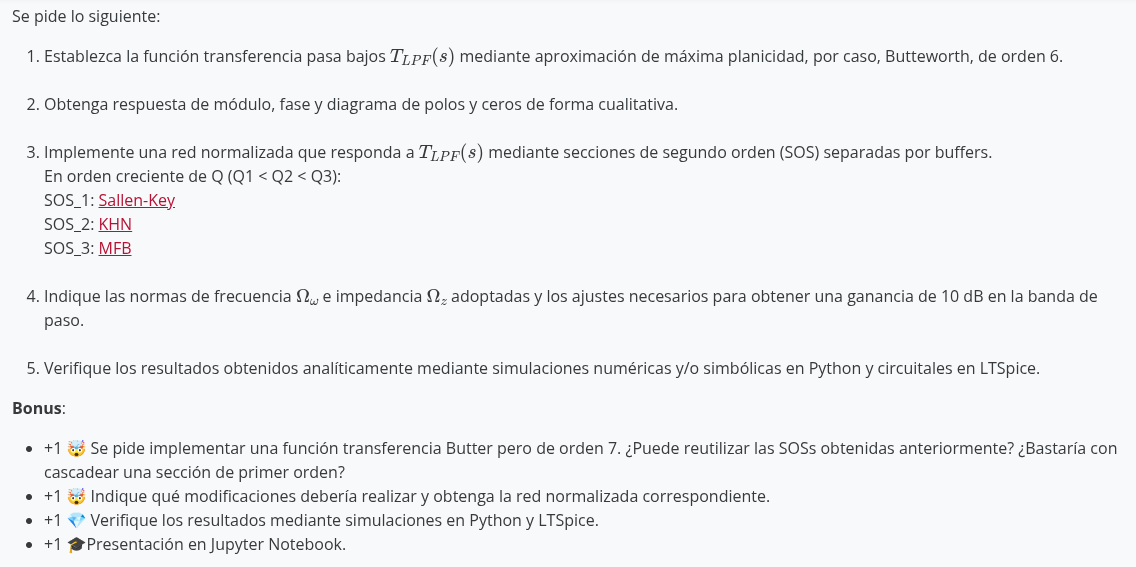

### Transferencia pasabajos mediante aproximación de máxima planicidad Butterworth:

$$
|T_{LPF}(s)|^2 = \left.{\frac{1}{1+{\omega}^{2n}}}\right|_{\omega = \frac{s}{j}} = \frac{1}{1+(-1)^n \cdot s^{2n}} = T(s) \cdot T(-s)
$$

#### Reemplazamos $n=6$:

$$
|T_{LPF}(s)|^2 = \frac{1}{1+(-1)^6 \cdot s^{12}} = \frac{1}{1+s^{12}} = T(s) \cdot T(-s) = {\frac{1}{s^6+a\cdot s^5+b\cdot s^4 + c\cdot s^3+d\cdot s^2 +e\cdot s+1}}\cdot{\frac{1}{s^6-a\cdot s^5+b\cdot s^4 - c\cdot s^3+d\cdot s^2 -e\cdot s+1}}
$$

#### El planteo nos queda muy complejo y tendríamos demasiadas variables en juego que ajustar, pero podemos simplificar el análisis como 3 orden 2 en cascada, considerando cada sección independiente separadas con buffers:

$$
T(s) \cdot T(-s) = {\frac{1}{s^2+a_1 \cdot s + 1}} \cdot {\frac{1}{s^2+a_2 \cdot s + 1}} \cdot {\frac{1}{s^2+a_3 \cdot s + 1}} \cdot {\frac{1}{s^2-a_1 \cdot s + 1}} \cdot {\frac{1}{s^2-a_2 \cdot s + 1}} \cdot {\frac{1}{s^2-a_3 \cdot s + 1}}
$$

#### En particular nos quedará que cada sección $S$ estará dada por:
$$
T_{Sn}(s) = \frac{1}{s^2+\frac{1}{Q_{Sn}}\cdot s+1}
$$
#### Donde al tener un orden 6 par, Q quedará como:
$$
Q_{Sn} = \frac{1}{2\cdot cos({\frac{\pi}{2 \cdot 6}}+{\frac{k\cdot \pi}{6}})}
$$
$$
\left. Q_{S1}\right|_{k=0} = \frac{1}{2\cdot cos({\frac{\pi}{12}})} = \frac{\sqrt{6} - \sqrt{2}}{2} \approx 0,5176
$$
$$
\left. Q_{S2}\right|_{k=1} = \frac{1}{2\cdot cos({\frac{\pi}{4}})} = \frac{\sqrt{2} }{2} \approx 0,707
$$
$$
\left. Q_{S3}\right|_{k=2} = \frac{1}{2\cdot cos({\frac{5\pi}{12}})} = \frac{\sqrt{6} + \sqrt{2}}{2} \approx 1,932
$$

#### Importación de librerías a usar:

In [2]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

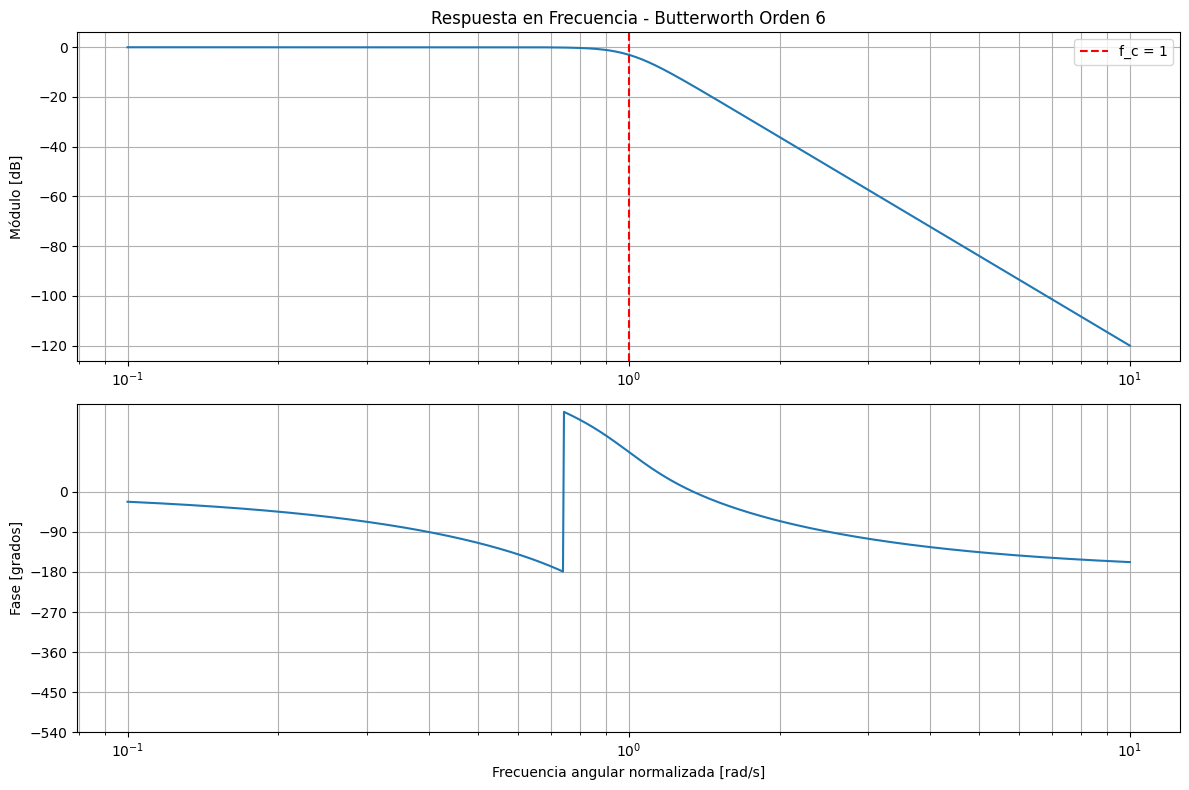

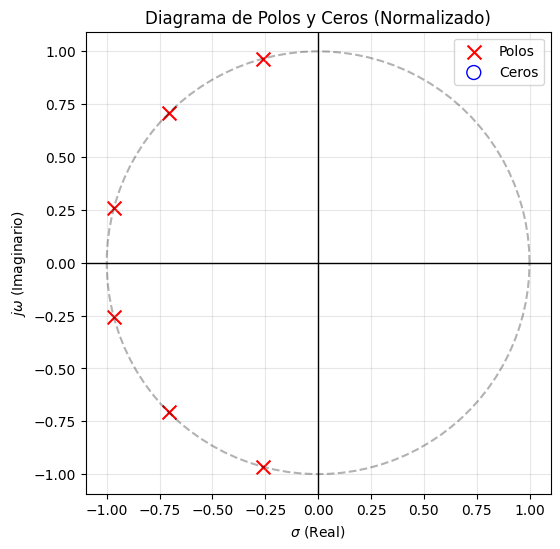

In [8]:

# 1. Definición del filtro Butterworth de orden 6
n = 6
fs = 1000  # Frecuencia de muestreo
low_pass = signal.butter(n, 1, btype='low', analog=True, output='sos')
# También obtenemos ceros, polos y ganancia (zpk) para el diagrama
z, p, k = signal.butter(n, 1, btype='low', analog=True, output='zpk')

# 2. Respuesta en frecuencia (Módulo y Fase)
w, h = signal.freqs_zpk(z, p, k, worN=np.logspace(-1, 1, 1000))

# Creamos la figura
plt.figure(figsize=(12, 8))

# Subplot Módulo
plt.subplot(2, 1, 1)
plt.semilogx(w, 20 * np.log10(np.abs(h)))
plt.title('Respuesta en Frecuencia - Butterworth Orden 6')
plt.ylabel('Módulo [dB]')
plt.grid(True, which="both", ls="-")
plt.axvline(1, color='red', linestyle='--', label='f_c = 1')
plt.legend()

# Subplot Fase
plt.subplot(2, 1, 2)
plt.semilogx(w, np.angle(h, deg=True))
plt.ylabel('Fase [grados]')
plt.xlabel('Frecuencia angular normalizada [rad/s]')
plt.yticks([-90*i for i in range(7)]) # Marcas cada 90 grados
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

# 3. Diagrama de Polos y Ceros
plt.figure(figsize=(6, 6))
# Dibujamos círculo unitario
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)

# Graficamos Polos y Ceros
plt.scatter(np.real(p), np.imag(p), s=100, marker='x', color='red', label='Polos')
plt.scatter(np.real(z), np.imag(z), s=100, marker='o', facecolors='none', edgecolors='blue', label='Ceros')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Diagrama de Polos y Ceros (Normalizado)')
plt.xlabel('$\sigma$ (Real)')
plt.ylabel('$j\omega$ (Imaginario)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

### Simulación LTSpice:

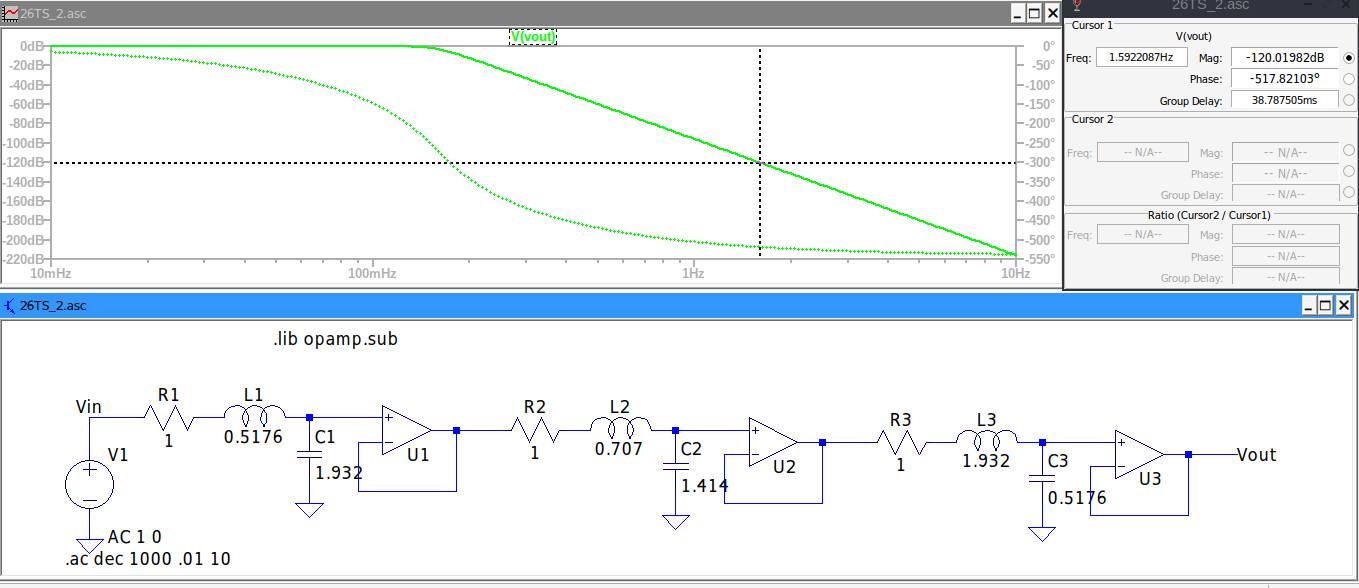

#### LA simulación básica pasiva en LTSpice con los Q hallados verifican el análisis.
### Bastaría con convertir el buffer final en un no inversor para conseguir la ganancia de 10dB

### Filtro orden 7:
#### Se podría usar la misma topología y agregar 1 etapa más de 1er orden que agregue el polo real para obtener el filtro de orden 7, pudiendo usar lo ya implementado

### Análisis nodal circuito Sallen-Key pasabajos:
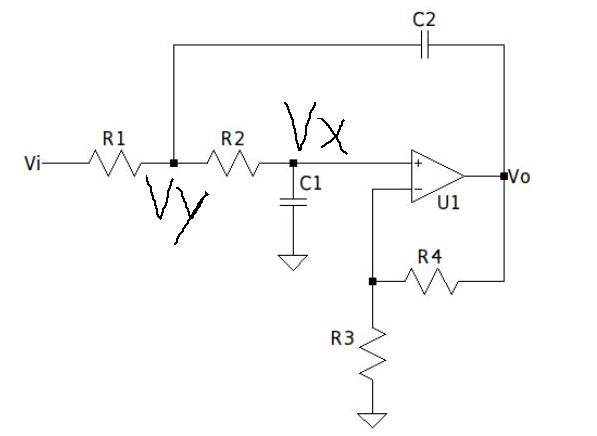
#### Asumo operacional realimentado V(-) = V(+)
#### Nodo Vy:
$$
Vy \cdot (G1+G2+SC2)-Vi \cdot G2-Vx \cdot G2-Vo \cdot SC2 = 0
$$
#### Nodo Vx V(-):
$$
Vx \cdot (G4+G3) - Vo \cdot G4 = 0
$$
#### Nodo Vx V(+):
$$
(Vy-Vx) \cdot G2 - Vx \cdot SC1 = 0
$$
#### Resolviendo nos queda:
$$
\frac{Vo}{Vi} = T_{(S)}=R4 \cdot \frac{\frac{G1G2}{C1C2}}{S^2+S \cdot \left( \frac{G1}{C2} - \frac{G2G3}{C1G4} \right) + \frac{G1G2}{C1C2}}
$$
#### Donde:
$$
{\omega_0}^2 = \frac{G1G2}{C1C2}
$$
$$
\frac{\omega_0}{Q} = \frac{G1}{C2} - \frac{G2G3}{C1G4}
$$
$$
K = R4
$$
#### Normalizando nomenclatura nos queda:
$$
T_{(S)} = K \cdot \frac{{\omega_0}^2}{S^2+S \cdot \frac{\omega_0}{Q} + {\omega_0}^2}
$$

### Verificación de la transferencia con SymPy:

In [7]:
Y1, Y2, Y3, Y4, Y5, Y6 = sp.symbols("Y1, Y2, Y3, Y4, Y5, Y6")
V1, V2, V3, V4 = sp.symbols("V1, V2, V3, V4")
G1, G2, G3, G4, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, G4, C1, C2, wt, w0", real = True, posistive = True) 
s = sp.symbols('S')

# Y1-Y4 -> G1-G4 , Y5-Y6 -> C1, C2 , V3 = Vy, V4 = Vx
aa = sp.solve([ 
                V3*(Y1+Y2+Y6) - V1*Y1 - V2*Y6 - V4*Y2, 
                V4*(Y4+Y3) - V2*Y4,
                V3*Y2 - V4*Y2 - V4*Y5
                ], 
                [V2, V3, V4])
T = sp.simplify(aa[V2]/V1)
print_latex(a_equal_b_latex_s('T(S)', T))

T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: G4,
    Y5: s*C1,
    Y6: s*C2
})
print_latex(a_equal_b_latex_s('T(S)', T_s))
T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)
print_latex(a_equal_b_latex_s('T(S)', T_s))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### La verificación simbólica no queda claro el por qué de las diferencias, si es un análisis fallido del análisis nodal, la realización de la verificación, o si son iguales trabajando los términos.